2026-07-31 15:44:45,900 [INFO] Bắt đầu tính toán Technical Indicators & Macro Features...


Kích thước dữ liệu gốc: (1566, 5)


2026-07-31 15:44:48,600 [INFO] Hoàn tất. Tổng số features (bao gồm vĩ mô): 21
2026-07-31 15:44:48,600 [INFO] Đã loại bỏ 69 dòng NaN ở đầu chuỗi dữ liệu.


Kích thước dữ liệu sau khi thêm Features: (1497, 21)


,RSI_14,Stoch_k,ROC,BBU_20_2.0,BBL_20_2.0,ATR,OBV,CMF,DXY,SP500
Date,,,,,,,,,,
2025-12-25,56.716688,58.322597,0.000000,23381.752237,22491.917294,575.182408,7.997895e+09,-0.020026,97.980003,6932.049805
2025-12-26,56.716688,58.322597,0.000000,23328.376183,22613.419312,577.333166,8.022265e+09,0.003044,98.019997,6929.939941
2025-12-29,56.716688,58.322597,0.877944,23195.454080,22819.275192,579.330298,8.033713e+09,0.018253,98.040001,6905.740234
2025-12-30,56.716688,58.322597,0.000000,23114.397037,22939.612106,581.184777,8.045770e+09,-0.016217,98.239998,6896.240234
2025-12-31,56.716688,58.322597,0.000000,23114.397037,22939.612106,582.906794,8.069595e+09,-0.033470,98.279999,6845.500000


Đã lưu bộ dữ liệu Feature tại: ../data/processed/MBB_features.parquet


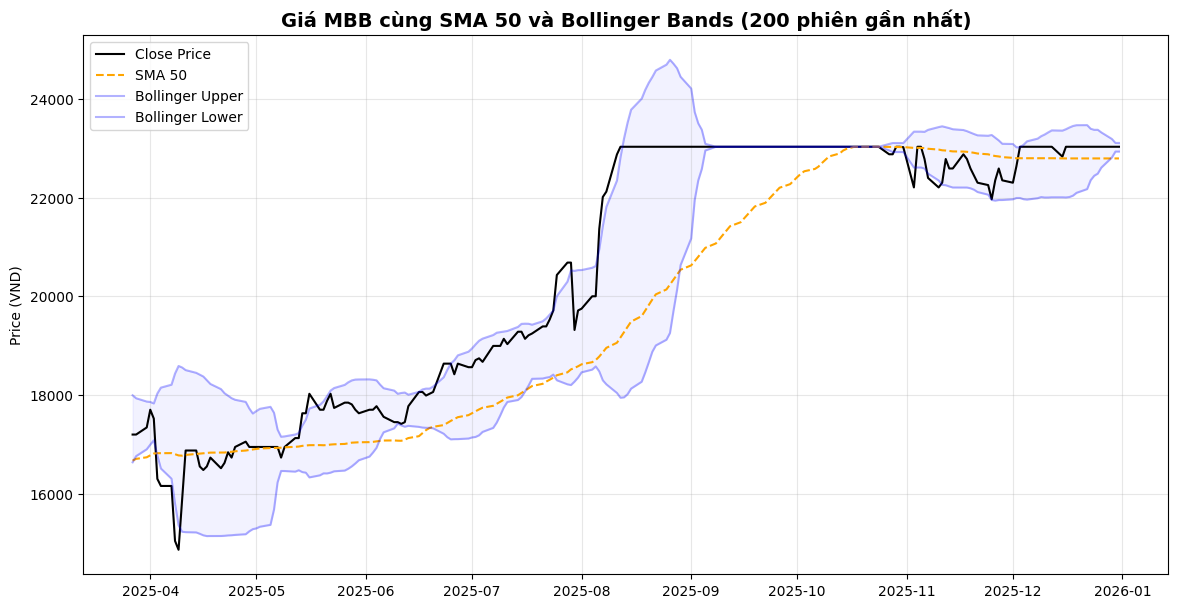

In [1]:
# Cell 1: Import
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from utils.feature_engineer import TechnicalFeatures

# Tự động reload lại code nếu sửa file .py
%load_ext autoreload
%autoreload 2

# Cell 2: Đọc dữ liệu
df_clean = pd.read_parquet("../data/processed/MBB_cleaned.parquet")
print("Kích thước dữ liệu gốc:", df_clean.shape)

# Cell 3: Sinh Feature Đặc trưng
te = TechnicalFeatures(df_clean)
df_features = te.generate_all_features()

print(f"Kích thước dữ liệu sau khi thêm Features: {df_features.shape}")
# Hiển thị 5 dòng, 10 cột cuối
display(df_features.iloc[-5:, -10:])

# Cell 4: Lưu dữ liệu để huấn luyện ML
output_path = "../data/processed/MBB_features.parquet"
df_features.to_parquet(output_path)
print(f"Đã lưu bộ dữ liệu Feature tại: {output_path}")

# Cell 5: Trực quan hóa kiểm tra (Close, SMA50 và Bollinger Bands)
plt.figure(figsize=(14, 7))

# Lấy 200 ngày gần nhất để biểu đồ không bị quá dày đặc
plot_df = df_features.tail(200)

plt.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black', linewidth=1.5)
plt.plot(plot_df.index, plot_df['SMA_50'], label='SMA 50', color='orange', linestyle='--')
plt.plot(plot_df.index, plot_df['BBU_20_2.0'], label='Bollinger Upper', color='blue', alpha=0.3)
plt.plot(plot_df.index, plot_df['BBL_20_2.0'], label='Bollinger Lower', color='blue', alpha=0.3)
plt.fill_between(plot_df.index, plot_df['BBL_20_2.0'], plot_df['BBU_20_2.0'], color='blue', alpha=0.05)

plt.title("Giá MBB cùng SMA 50 và Bollinger Bands (200 phiên gần nhất)", fontsize=14, fontweight="bold")
plt.ylabel("Price (VND)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()